# **Hydrograph Visualization**

### Analyze rainfall–runoff dynamics in the Gazelle Valley catchment  
### *(Currently using rainfall data exclusively from the !Givat Ram! rain gauge)*

This notebook loads rainfall (Givat Ram only) and discharge datasets, extracts hydrological events,  
and generates clean scientific hydrographs using two complementary tools:

- **Event-based hydrographs** (from the flow–rain events table)  
- **Custom time-range hydrographs** (user-defined datetime window)

Dual-axis figures display discharge and Givat Ram rainfall intensity with clear, publication-quality formatting.


## Import Libraries and Define Paths

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# ---------- paths ----------
FLOW_EVENTS_PATH = r"D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\flow_rain_events.csv"
DISCHARGE_PATH   = r"D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\discharge_rakafot_gazelle.csv"
RAIN_PATH        = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\givat_ram\20231030_20251117_processed.csv"

## Functions

In [2]:
def load_flow_events(path):
    """
    Load and clean the flow_rain_events table.
    We keep rows from index 2 and rename the relevant columns.
    """
    df_raw = pd.read_csv(path)
    
    # Data starts from row 2 (0 and 1 are header-like rows)
    df = df_raw.iloc[2:].copy()

    # Rename the columns we need
    df = df.rename(columns={
        "Unnamed: 0": "season_index",
        "rain": "rain_event_start",
        "rain.1": "rain_event_end"
    })
    
    # Convert types
    df["season_index"] = df["season_index"].astype(int)
    df["rain_event_start"] = pd.to_datetime(df["rain_event_start"])
    df["rain_event_end"] = pd.to_datetime(df["rain_event_end"])
    
    return df


def load_discharge(path):
    """
    Load discharge data and build a datetime column in local time.
    """
    df = pd.read_csv(path)
    # Date is in dd/mm/yyyy, Time is hh:mm:ss
    df["datetime"] = pd.to_datetime(
        df["Date"] + " " + df["Time"],
        dayfirst=True
    )
    return df


def load_rain(path):
    """
    Load processed rain data.
    Assumes 'date_time' is already a local datetime.
    """
    df = pd.read_csv(path)
    df["date_time"] = pd.to_datetime(df["date_time"])
    return df
def plot_hydrograph_for_event(
        season_index,
        flow_events_path=FLOW_EVENTS_PATH,
        discharge_path=DISCHARGE_PATH,
        rain_path=RAIN_PATH,
        xlim=None,
        ylim_left=None,
        ylim_right=None):


    # --- load data ---
    events_df = load_flow_events(flow_events_path)
    discharge_df = load_discharge(discharge_path)
    rain_df = load_rain(rain_path)

    # --- event times ---
    event_row = events_df.loc[events_df["season_index"] == season_index].iloc[0]
    start = event_row["rain_event_start"]
    end = event_row["rain_event_end"]

    # --- slice data ---
    discharge_sel = discharge_df[(discharge_df["datetime"] >= start) &
                                 (discharge_df["datetime"] <= end)].copy()

    rain_sel = rain_df[(rain_df["date_time"] >= start) &
                       (rain_df["date_time"] <= end)].copy()

    # --------------------------------------------------------
    # PLOTTING
    # --------------------------------------------------------
    plt.style.use('seaborn-whitegrid')
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 1.2

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    # --- discharge line ---
    q = discharge_sel["Computed Discharge(m³/s)"]
    qmax = q.max()

    ax1.plot(
        discharge_sel["datetime"],
        q,
        color='black',
        linewidth=2,
        label="Discharge"
    )

    # --- rainfall intensity bars ---
    if not rain_sel.empty:
        ax2.bar(
            rain_sel["date_time"],
            rain_sel["rain_intens_10min_mm_hr"],
            width=0.006,  # ~10 min window in days
            color='#0000FF',
            alpha=0.45,
            label="Rain intensity [mm/h]"
        )

    # --------------------------------------------------------
    # X LIMITS
    # --------------------------------------------------------
    if xlim is None:
        ax1.set_xlim(start, end)
    else:
        ax1.set_xlim(xlim)

    # Format X axis as day hour:minute
    ax1.xaxis.set_major_formatter(DateFormatter("%d/%m %H"))

    # --------------------------------------------------------
    # Y LIMITS + TICKS
    # --------------------------------------------------------
    # LEFT axis
    if ylim_left is None:
        ax1.set_ylim(0, qmax * 2)
    else:
        ax1.set_ylim(ylim_left)

    nice_ticks_q = MaxNLocator(nbins=4).tick_values(0, qmax)
    ax1.set_yticks(nice_ticks_q)

    # RIGHT axis
    if not rain_sel.empty:
        rmax = rain_sel["rain_intens_10min_mm_hr"].max()

        if ylim_right is None:
            ax2.set_ylim(rmax * 2.2, 0)
        else:
            ax2.set_ylim(ylim_right[1], ylim_right[0])

        nice_ticks_r = MaxNLocator(nbins=4).tick_values(0, rmax)
        ax2.set_yticks(nice_ticks_r[::-1])
    else:
        ax2.set_ylim(10, 0)

    # --------------------------------------------------------
    # LABELS + TITLE
    # --------------------------------------------------------
    ax1.set_xlabel("Time", fontsize=18)
    ax1.set_ylabel("Discharge [m³/s]", fontsize=18)
    ax2.set_ylabel("Rainfall intensity [mm/h]", fontsize=18)

    ax1.yaxis.set_label_coords(-0.06, 0.20)
    ax2.yaxis.set_label_coords(1.06, 0.80)

    ax1.tick_params(axis='both', labelsize=14, width=1.2)
    ax2.tick_params(axis='both', labelsize=14, width=1.2)

    # Frame styling
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')

    # Legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               fontsize=14, loc='upper right', framealpha=0.6)

    fig.suptitle(f"Hydrograph — Event {season_index}",
                 fontsize=20, fontweight='bold')

    plt.tight_layout()
    plt.close(fig)
    return fig

In [3]:
def plot_hydrograph_for_timerange(
        start_time,
        end_time,
        discharge_path=DISCHARGE_PATH,
        rain_path=RAIN_PATH,
        xlim_hours=None,
        ylim_left=None,
        ylim_right=None):


    # --- convert to timestamps ---
    start_time = pd.to_datetime(start_time)
    end_time   = pd.to_datetime(end_time)

    # --- load data ---
    discharge_df = load_discharge(discharge_path)
    rain_df = load_rain(rain_path)

    # --- slice data ---
    discharge_sel = discharge_df[(discharge_df["datetime"] >= start_time) &
                                 (discharge_df["datetime"] <= end_time)].copy()

    rain_sel = rain_df[(rain_df["date_time"] >= start_time) &
                       (rain_df["date_time"] <= end_time)].copy()

    # --------------------------------------------------------
    # PLOTTING
    # --------------------------------------------------------
    plt.style.use('seaborn-whitegrid')
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 1.2

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    # --- discharge ---
    q = discharge_sel["Computed Discharge(m³/s)"]
    qmax = q.max()

    ax1.plot(
        discharge_sel["datetime"],
        q,
        color='black',
        linewidth=2,
        label="Discharge"
    )

    # --- rainfall intensity ---
    if not rain_sel.empty:
        # Delta for bar width (in minutes)
        if len(rain_sel) > 1:
            dt = (rain_sel["date_time"].iloc[1] - rain_sel["date_time"].iloc[0]).total_seconds() / 60.0
        else:
            dt = 10  # default 10min

        ax2.bar(
            rain_sel["date_time"],
            rain_sel["rain_intens_10min_mm_hr"],
            width=pd.Timedelta(minutes=dt),
            color='#0000FF',
            alpha=0.45,
            label="Rain intensity [mm/h]"
        )

    # --------------------------------------------------------
    # X AXIS: datetime ticks
    # --------------------------------------------------------
    ax1.set_xlim(start_time, end_time)

    # Formatting: dd/mm HH:MM
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
    fig.autofmt_xdate(rotation=30)

    # --------------------------------------------------------
    # Y limits + ticks
    # --------------------------------------------------------
    # LEFT axis
    if ylim_left is None:
        ax1.set_ylim(0, qmax * 2)
    else:
        ax1.set_ylim(ylim_left)

    nice_ticks_q = MaxNLocator(nbins=4).tick_values(0, qmax)
    ax1.set_yticks(nice_ticks_q)

    # RIGHT axis
    if not rain_sel.empty:
        rmax = rain_sel["rain_intens_10min_mm_hr"].max()

        if ylim_right is None:
            ax2.set_ylim(rmax * 2.2, 0)
        else:
            ax2.set_ylim(ylim_right[1], ylim_right[0])

        nice_ticks_r = MaxNLocator(nbins=4).tick_values(0, rmax)
        ax2.set_yticks(nice_ticks_r[::-1])
    else:
        ax2.set_ylim(10, 0)

    # --------------------------------------------------------
    # LABELS + TITLE
    # --------------------------------------------------------
    ax1.set_xlabel("Time [dd/mm HH:MM]", fontsize=18)
    ax1.set_ylabel("Discharge [m³/s]", fontsize=18)
    ax2.set_ylabel("Rainfall intensity [mm/h]", fontsize=18)

    ax1.yaxis.set_label_coords(-0.06, 0.20)
    ax2.yaxis.set_label_coords(1.06, 0.80)

    ax1.tick_params(axis='both', labelsize=14, width=1.2)
    ax2.tick_params(axis='both', labelsize=14, width=1.2)

    # Frame stylings
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')

    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               fontsize=14, loc='upper right', framealpha=0.6)

    # Title
    fig.suptitle(f"Hydrograph\n{start_time}  →  {end_time}",
                 fontsize=20, fontweight='bold')

    plt.tight_layout()
    plt.close(fig)
    return fig


## Flow event list

In [7]:
load_flow_events(FLOW_EVENTS_PATH)

,season_index,discharge,discharge.1,discharge.2,rain_event_start,rain_event_end,discharge.3,discharge.4,gazelle_valley,gazelle_valley.1,gazelle_valley.2,gazelle_valley.3,ziv,ziv.1,ziv.2,ziv.3,givat_ram,givat_ram.1,givat_ram.2,givat_ram.3
2,101,2023-11-01 13:50:00,0.617218034,1773.3019457999994,2023-10-31 12:20:00,2023-11-04 11:00:00,1.6120926779999996,2023-11-01 12:20:00,26.499999999999996,0.06083368596226414,39.0,2023-11-01 13:40:00,13.6,0.11853622632352938,42.0,2023-11-01 13:40:00,7.800000000000001,0.20667854846153838,15.0,2023-11-01 12:20:00
3,102,2023-11-14 16:40:00,0.063549752,39.911987100000005,2023-11-13 16:30:00,2023-11-15 17:05:00,0.03628362463636364,2023-11-14 16:30:00,2.7,0.013438379494949497,10.2,2023-11-14 16:20:00,9.0,0.004031513848484849,17.400000000000002,2023-11-14 16:20:00,2.9000000000000004,0.012511594702194357,8.399999999999999,2023-11-14 16:30:00
4,103,2023-11-20 02:55:00,0.39405199,7530.1636353,2023-11-18 14:20:00,2023-11-22 16:15:00,6.845603304818182,2023-11-19 14:20:00,51.400000000000006,0.13318294367350547,19.8,2023-11-19 17:40:00,68.60000000000001,0.099790135638749,55.8,2023-11-19 16:50:00,57.099999999999994,0.11988797381467921,33.0,2023-11-19 17:00:00
5,104,2023-11-27 13:30:00,0.21835827,2319.0868560000004,2023-11-26 04:05:00,2023-11-28 18:10:00,2.108260778181818,2023-11-27 04:05:00,24.800000000000004,0.08501051524926684,9.0,2023-11-27 07:30:00,23.1,0.09126670035419125,10.8,2023-11-27 07:30:00,19.8,0.1064778170798898,7.800000000000001,2023-11-27 09:20:00
6,105,2023-12-05 17:50:00,0.166976605,545.8095267000001,2023-12-04 16:20:00,2023-12-07 12:40:00,0.49619047881818196,2023-12-05 16:20:00,13.8,0.03595583179841898,10.2,2023-12-05 15:50:00,13.600000000000001,0.03648459403074867,6.0,2023-12-05 15:50:00,11.2,0.04430272132305196,7.800000000000001,2023-12-05 16:00:00
7,106,2023-12-13 06:00:00,0.247911568,1022.0170719,2023-12-12 04:35:00,2023-12-14 15:30:00,0.929106429,2023-12-13 04:35:00,12.4,0.07492793782258064,9.0,2023-12-13 05:40:00,11.100000000000001,0.08370328189189187,9.0,2023-12-13 04:30:00,10.3,0.0902045076699029,6.6000000000000005,2023-12-13 08:20:00
8,107,2023-12-24 06:05:00,0.306211788,5235.336201,2023-12-21 05:55:00,2023-12-25 16:55:00,4.759396546363637,2023-12-22 05:55:00,34.300000000000004,0.13875791680360455,10.2,2023-12-24 05:00:00,31.100000000000005,0.15303525872551885,7.200000000000001,2023-12-24 05:10:00,31.0,0.1535289208504399,11.4,2023-12-24 10:10:00
9,108,2024-01-02 09:35:00,0.283269237,10427.1083205,2024-01-01 02:40:00,2024-01-03 21:20:00,9.479189382272727,2024-01-02 02:40:00,0.8,11.848986727840908,2.4000000000000004,2024-01-02 07:30:00,1.4000000000000001,6.770849558766233,4.2,2024-01-02 07:30:00,0.7000000000000001,13.541699117532467,2.4000000000000004,2024-01-02 07:40:00
10,109,2024-01-12 04:50:00,0.292368954,10366.9533624,2024-01-09 23:50:00,2024-01-16 11:40:00,9.424503056727271,2024-01-10 23:50:00,59.900000000000006,0.15733727974502956,8.4,2024-01-14 01:50:00,63.7,0.1479513823662052,9.0,2024-01-12 04:20:00,55.8,0.16889790424242423,8.399999999999999,2024-01-11 16:10:00
11,110,2024-01-26 17:15:00,0.399168274,17738.155378012,2024-01-22 13:20:00,2024-01-31 11:05:00,16.12559579819273,2024-01-23 13:20:00,106.69999999999999,0.1511302324104286,26.4,2024-01-26 17:00:00,115.30000000000001,0.1398577259166759,25.8,2024-01-26 17:00:00,106.60000000000001,0.15127200561156406,24.0,2024-01-26 17:10:00


### Plot hydrograph with event number

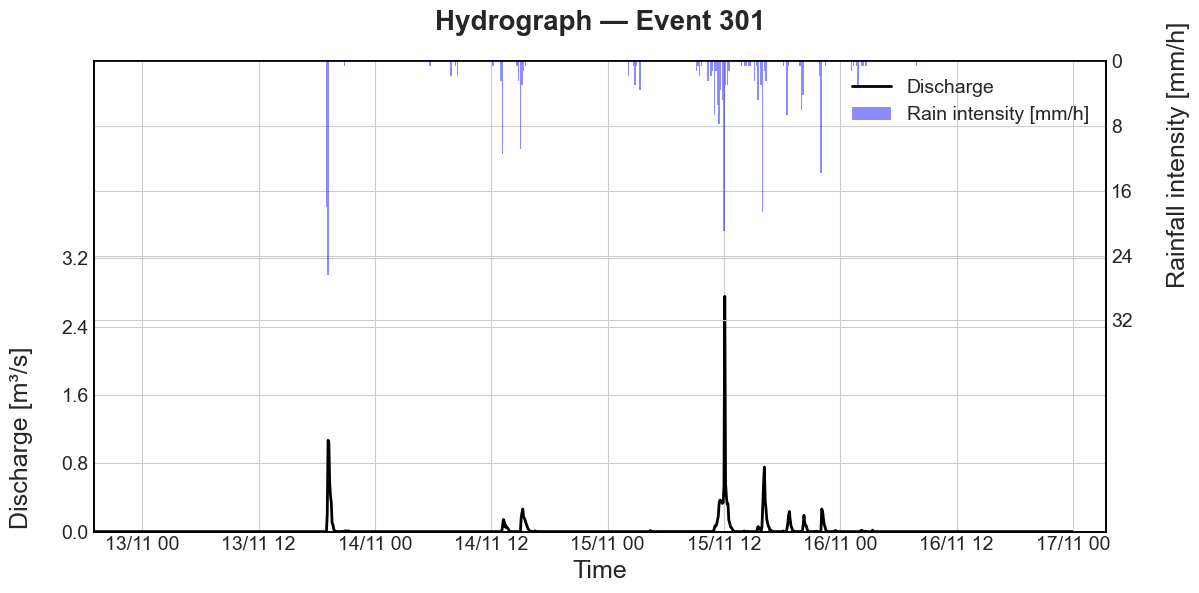

In [4]:
# Just change 301 to any season_index you want:
plot_hydrograph_for_event(301)

### Plot hydrograph with date and time

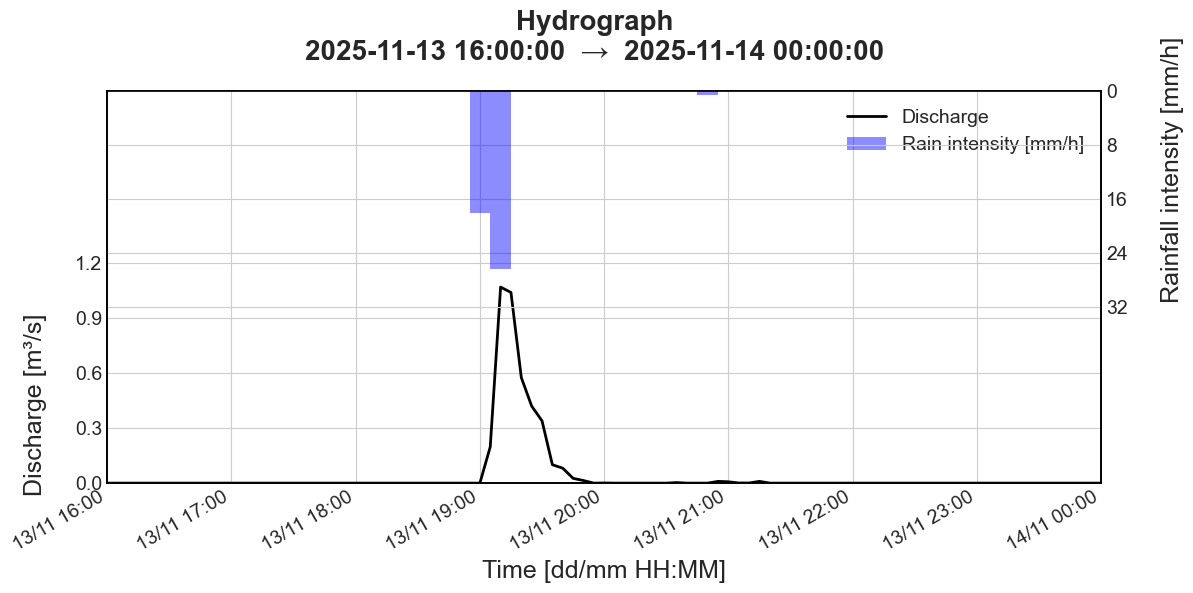

In [9]:
plot_hydrograph_for_timerange(
    pd.Timestamp("2025-11-13 16:00"),
    pd.Timestamp("2025-11-14 00:00")
)
